## Setup & Imports


In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import natsort
import numpy as np

from src import scattering

## Load Dataset


In [2]:
neta = nsc = 80

In [3]:
training_data_path = Path("../../..").resolve() / "data/3510tri_rotation"

with h5py.File(training_data_path / "eta.h5", "r") as f:
    eta_re = np.transpose(
        f[list(f.keys())[0]][:1, :].reshape(-1, neta, neta), axes=(0, 2, 1)
    )

# Loading and preprocessing scattering data
with h5py.File(training_data_path / "scatter.h5", "r") as f:
    keys = natsort.natsorted(f.keys())

    # Process real part of scattering data
    tmp1 = f[keys[3]][:1, :]
    tmp2 = f[keys[4]][:1, :]
    tmp3 = f[keys[5]][:1, :]
    scatter_re = np.stack((tmp1, tmp2, tmp3), axis=-1).reshape(-1, nsc, nsc, 3)
    # Process imaginary part of scattering data
    tmp1 = f[keys[0]][:1, :]
    tmp2 = f[keys[1]][:1, :]
    tmp3 = f[keys[2]][:1, :]
    scatter_im = np.stack((tmp1, tmp2, tmp3), axis=-1).reshape(-1, nsc, nsc, 3)

    # Combine real and imaginary parts
    scatter = np.transpose(-scatter_re - 1j * scatter_im, axes=(0, 2, 1, 3)).astype(
        np.complex64
    )

In [4]:
eta_re.shape

(1, 80, 80)

In [5]:
scatter.shape

(1, 80, 80, 3)

## Scattering Operator Setup


In [6]:
import importlib

importlib.reload(scattering)

<module 'src.scattering' from '/home/bzhang388/back_projection_diffusion/data_generation/jax_forward_scattering/src/scattering.py'>

In [7]:
operator = scattering.Scattering(
    lx=1.0,
    ly=1.0,
    nx=80,
    ny=80,
    frequencies=(2.5, 5.0, 10.0),
    num_directions=80,
    receiver_radius=0.5,
    order=8,
    npml=20,
    sigma_max=80,
)

## Forward Pass Comparison


In [8]:
x0 = np.asarray(eta_re[0:1], dtype=np.float32)
y = operator.forward(x0, unnormalize=False)

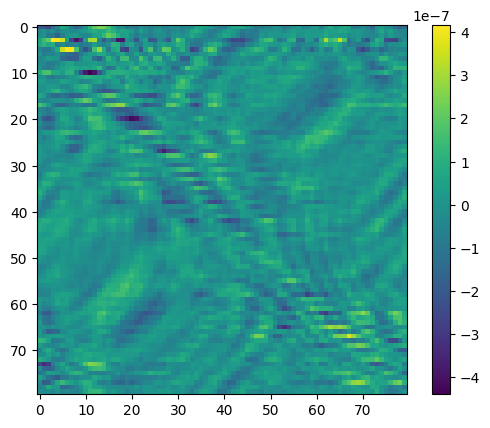

In [9]:
plt.imshow((y[0, :, :, 2] - scatter[0, :, :, 2]).real)
plt.colorbar()

## Differential Operator Checks


In [10]:
# check _jacobian_action_single
# should see second order remainder decay until it hits machine precision at 1e-7
x0 = np.asarray(eta_re[0], dtype=np.float32)

rng = np.random.default_rng(0)
dx = rng.standard_normal((operator.ny, operator.nx)).astype(np.float32)
dx /= np.linalg.norm(dx)

F0 = np.asarray(operator.forward(x0[None], unnormalize=False))[0, :, :, 0]
Jdx = operator._jacobian_action_single(x0, dx, frequency_index=0)

for eps in [1, 1e-1, 1e-2]:
    F1 = np.asarray(operator.forward((x0 + eps * dx)[None], unnormalize=False))[
        0, :, :, 0
    ]
    err_lin = np.linalg.norm(F1 - F0)
    err_rem = np.linalg.norm(F1 - F0 - eps * Jdx)
    print(f"eps={eps:.0e}  first-order={err_lin:.3e}  remainder={err_rem:.3e}")

eps=1e+00  first-order=2.209e-01  remainder=1.284e-03
eps=1e-01  first-order=2.210e-02  remainder=1.285e-05
eps=1e-02  first-order=2.210e-03  remainder=1.436e-07


In [11]:
# check _adjoint_jacobian_action_single
# inner products should agree with each other
x0 = np.asarray(eta_re[0], dtype=np.float32)

rng = np.random.default_rng(1)
dx = rng.standard_normal((operator.ny, operator.nx)).astype(np.float32)
z = (
    rng.standard_normal((operator.num_directions, operator.num_directions))
    + 1j * rng.standard_normal((operator.num_directions, operator.num_directions))
).astype(np.complex64)

Jdx = operator._jacobian_action_single(x0, dx, frequency_index=0)
Jtz = operator._adjoint_jacobian_action_single(x0, z, frequency_index=0)

lhs = np.real(np.vdot(Jdx, z))
rhs = np.vdot(dx, Jtz)
relerr = abs(lhs - rhs) / max(1.0, abs(lhs), abs(rhs))

print("lhs =", lhs)
print("rhs =", rhs)
print("relative error =", relerr)

lhs = -4.773916065013156
rhs = -4.7739186
relative error = 5.37017840222617e-07


## Jacobian/Adjoint Visual Diagnostics


In [12]:
Feta0 = operator._jacobian_action_single(np.zeros_like(x0), x0, frequency_index=0)

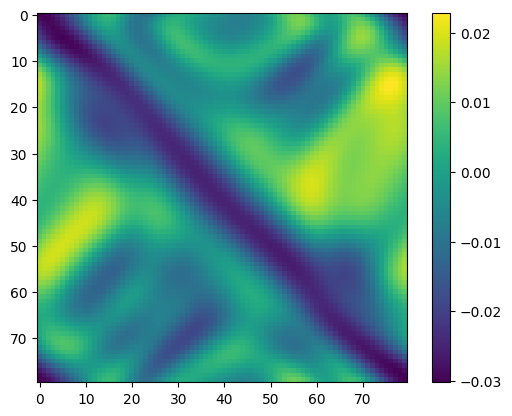

In [13]:
plt.imshow(Feta0.real)
plt.colorbar()

In [14]:
x_ref = np.zeros((operator.ny, operator.nx), dtype=np.float32)
adj0 = operator._adjoint_jacobian_action_single(
    x_ref, scatter[0, :, :, 0], frequency_index=0
)
adj1 = operator._adjoint_jacobian_action_single(
    x_ref, scatter[0, :, :, 1], frequency_index=1
)
adj2 = operator._adjoint_jacobian_action_single(
    x_ref, scatter[0, :, :, 2], frequency_index=2
)

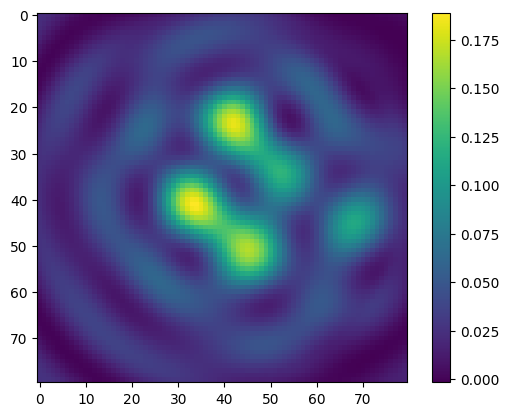

In [15]:
plt.imshow(adj0)
plt.colorbar()

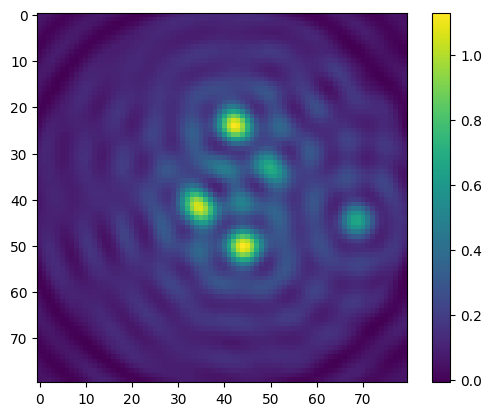

In [16]:
plt.imshow(adj1)
plt.colorbar()

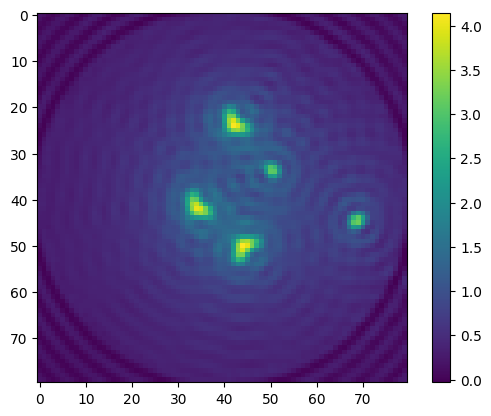

In [17]:
plt.imshow(adj2)
plt.colorbar()

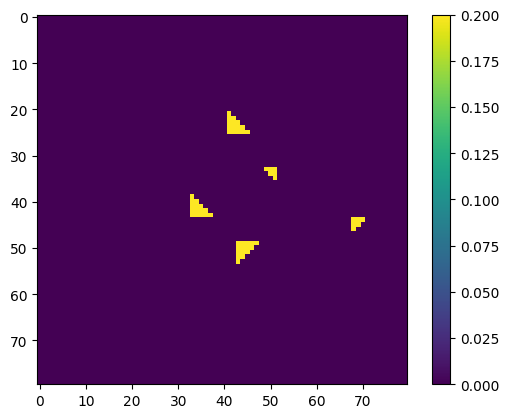

In [18]:
plt.imshow(eta_re[0])
plt.colorbar()

In [19]:
adj = operator.adjoint_jacobian_action(x_ref[None], scatter[0:1, ...])

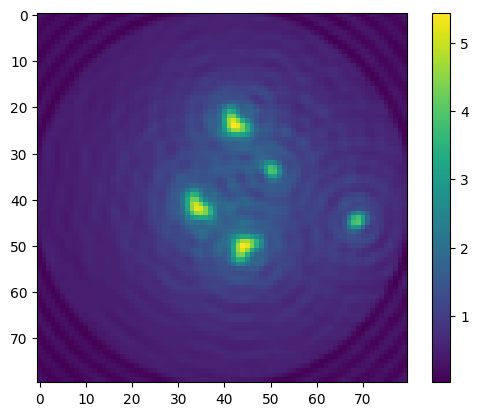

In [20]:
plt.imshow(adj[0, :, :, 0])
plt.colorbar()